<a href="https://colab.research.google.com/github/aisha-partha/AIMLOps-MiniProjects/blob/mp_8/M6_MP2_Retrieval_Augmented_Generation(RAG)_G4_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Retrieval Augmented Generation (RAG) - M6-MP2 - Group-4**

**OBJECTIVES:**

1. Load the document files (1 point)
2. Split the loaded documents into chunks (1 point)
3. Create embeddings and store in Vector Database (3 points)
4. Perform the retrieval augmented generation by integrating with LLM (3 points)
5. Frame at least five logical questions relevant to the knowledge base and
demonstrate relevant answers from the RAG system (1 point)
6. Create a Gradio App where user can write the query and get the response from
the RAG system (1 point)
7. Deploy the application on HF Spaces [Optional]

In [1]:
!pip install openai
!pip install langchain-core
!pip install langchain-openai
!pip install langchain-community
!pip install chromadb
!pip install pypdf

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.5/383.5 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.4/76.4 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.0/78.0 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.9/318.9 kB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 6.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.4/50.4 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.9/400.9 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.9/141.9 kB 13.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 5.8 MB/s eta 0:00:00
  Attempting uninstall: tenacity
    Found existing installation: tenacity 9.0.0
    Uninstalling tenacity-9.0.0:
      Successfully uninstalled tenacity-9.0.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [20]:
import openai
import os

f = open('/content/OpenAPI Key.txt')
api_key = f.read()
os.environ['OPENAI_API_KEY'] = api_key
openai.api_key= os.getenv('OPENAI_API_KEY')

## **1. Loading the Document files**

In [2]:
from langchain_community.document_loaders import PyPDFLoader
# Load PDF
loaders = [
    # Duplicate documents on purpose
    PyPDFLoader("/content/M3-W1-AST1.pdf"),
    PyPDFLoader("/content/M3-W2-AST2.pdf"),
]
docs = []
for loader in loaders:
    docs.extend(loader.load())

In [3]:
print(docs[0].page_content)

M o d u l e
3 :
A S T - 1
TITLE:
Transitioning
from
Research
to
Production
Environment
LEARNING
OBJECTIVES:
At
the
end
of
the
experiment,
you
will
be
able
to
transition
from
the
research
environment
to
the
production
environment.
You
will
understand
the
concept
of
modularization
and
convert
the
model
developed
in
Jupyter
Notebook
into
different
modules
tailored
to
specific
functionalities:
Data
Manager,
Training,
Pipeline,
Predict,
etc.
You
will
be
able
to
understand
and
implement
the
following
aspects:
1.
VS
code
setup
and
understanding
interface
components
2.
Creating
virtual
environment,
installing
requirement,
running
.py
&
.ipynb
file
3.
Understanding
__name__
==
“__main__”
and
building
our
own
modules
4.
Modularization:
Converting
a
ML
model
from
research
environment
format
(Notebook)
to
product
environment
format
(.py
files)
A)
Creating
different
modules
specific
to
functionality:
Data
Manager,
Training,
Pipeline,
Predict
B)
Understanding
folder
structure
C)
Separating
configura

In [4]:
!pip install pdfminer.six

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 51.6 MB/s eta 0:00:00


In [5]:
from langchain_community.document_loaders import PDFMinerLoader

loaders = [
    PDFMinerLoader("/content/M3-W1-AST1.pdf"),
    PDFMinerLoader("/content/M3-W2-AST2.pdf"),
]

docs = []
for loader in loaders:
    docs.extend(loader.load())

In [6]:
print(docs[0].page_content)

Module 3: AST-1

TITLE: Transitioning from Research to Production Environment

LEARNING OBJECTIVES:

At the end of the experiment, you will be able to transition from the research environment to the
production environment. You will understand the concept of modularization and convert the
model developed in Jupyter Notebook into different modules tailored to specific functionalities:
Data Manager, Training, Pipeline, Predict, etc.

You will be able to understand and implement the following aspects:

1. VS code setup and understanding interface components
2. Creating virtual environment, installing requirement, running .py & .ipynb file
3. Understanding __name__ == “__main__” and building our own modules
4. Modularization: Converting a ML model from research environment format (Notebook)

to product environment format (.py files)

A) Creating different modules specific to functionality: Data Manager, Training,

Pipeline, Predict

B) Understanding folder structure
C) Separating configurat

## **2. Splitting the document - Different Chunking Methods**

In [7]:
%pip install -qU langchain-text-splitters

***A. Fixed Length Chunking***

1. How the text is split: by single character separator.
2. How the chunk size is measured: by number of characters.

In [8]:
from langchain_text_splitters import CharacterTextSplitter


splitter_1 = CharacterTextSplitter(
    separator="\n\n",
    chunk_size=500,
    chunk_overlap=100,
    length_function=len,
    is_separator_regex=False,
)

chunks_1 = []

for doc in docs:

    chunks = splitter_1.split_text(doc.page_content)

    # Combine chunks with their associated metadata
    for chunk in chunks:
        chunks_1.append({
            "chunk": chunk,
            "metadata": doc.metadata
        })

In [9]:
import pprint

pp = pprint.PrettyPrinter()

for i in chunks_1[0:2]:
    pp.pprint(i)

{'chunk': 'Module 3: AST-1\n'
          '\n'
          'TITLE: Transitioning from Research to Production Environment\n'
          '\n'
          'LEARNING OBJECTIVES:\n'
          '\n'
          'At the end of the experiment, you will be able to transition from '
          'the research environment to the\n'
          'production environment. You will understand the concept of '
          'modularization and convert the\n'
          'model developed in Jupyter Notebook into different modules tailored '
          'to specific functionalities:\n'
          'Data Manager, Training, Pipeline, Predict, etc.',
 'metadata': {'source': '/content/M3-W1-AST1.pdf'}}
{'chunk': 'You will be able to understand and implement the following '
          'aspects:\n'
          '\n'
          '1. VS code setup and understanding interface components\n'
          '2. Creating virtual environment, installing requirement, running '
          '.py & .ipynb file\n'
          '3. Understanding __name__ == “__mai

In [10]:
for i in chunks_1:
    if len(i['chunk']) > 500:
        print("##############################################\n")
        print("Chunks with length greater than 500 found:\n")
        pp.pprint(i)
        print("\n##############################################\n")

##############################################

Chunks with length greater than 500 found:

{'chunk': 'Types of Tests: Three types of tests can be designed: Unit test, '
          'Integration test\n'
          'and system test. A unit test is the smallest and simplest form of '
          'software testing.\n'
          'These tests are employed to assess a separable unit of software '
          'such as a class or a\n'
          'function for correctness, independent of the larger software system '
          'composed of many\n'
          'test verifies and passes individual units which are\n'
          'such unit components. A unit\n'
          'assembled into larger components. The integration tests are run on '
          'an assembled\n'
          'component to verify that it functions correctly, and finally, the '
          'system tests cover the\n'
          'end-to-end functionality of the system.',
 'metadata': {'source': '/content/M3-W2-AST2.pdf'}}

##########################

***B. Recursive Chunking***

1. How the text is split: by list of characters.
2. How the chunk size is measured: by number of characters.

In [11]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

In [12]:
splitter_2 = RecursiveCharacterTextSplitter(
    separators=["\n\n", "\n", " ", ""],
    chunk_size=300,
    chunk_overlap=100,
    length_function=len
)

chunks_2 = []

for doc in docs:

    chunks = splitter_2.split_text(doc.page_content)

    # Combine chunks with their associated metadata
    for chunk in chunks:
        chunks_2.append({
            "chunk": chunk,
            "metadata": doc.metadata
        })

In [13]:
for i in chunks_2[0:2]:
    pp.pprint(i)

{'chunk': 'Module 3: AST-1\n'
          '\n'
          'TITLE: Transitioning from Research to Production Environment\n'
          '\n'
          'LEARNING OBJECTIVES:',
 'metadata': {'source': '/content/M3-W1-AST1.pdf'}}
{'chunk': 'At the end of the experiment, you will be able to transition from '
          'the research environment to the\n'
          'production environment. You will understand the concept of '
          'modularization and convert the\n'
          'model developed in Jupyter Notebook into different modules tailored '
          'to specific functionalities:',
 'metadata': {'source': '/content/M3-W1-AST1.pdf'}}


In [14]:
for i in chunks_2:
    if len(i['chunk']) > 500:
        print("##############################################\n")
        print("Chunks with length greater than 500 found:\n")
        pp.pprint(i)
        print("\n##############################################\n")

In [15]:
chunks_2a = splitter_2.split_documents(docs)
chunks_2a[0]

Document(metadata={'source': '/content/M3-W1-AST1.pdf'}, page_content='Module 3: AST-1\n\nTITLE: Transitioning from Research to Production Environment\n\nLEARNING OBJECTIVES:')

***C. Semantic Based Chunking***

At a high level, this splits into sentences, then groups into groups of 3 sentences, and then merges one that are similar in the embedding space.

In [16]:
!pip install langchain_experimental

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.1/208.1 kB 4.9 MB/s eta 0:00:00


In [21]:
from langchain_experimental.text_splitter import SemanticChunker
from langchain_openai.embeddings import OpenAIEmbeddings

splitter_3 = SemanticChunker(OpenAIEmbeddings(),breakpoint_threshold_type="percentile")

chunks_3 = []

for doc in docs[0:1]:

    chunks = splitter_3.split_text(doc.page_content)

    # Combine chunks with their associated metadata
    for chunk in chunks:
        chunks_3.append({
            "chunk": chunk,
            "metadata": doc.metadata
        })

In [22]:
for i in chunks_3[0:1]:
    print(i)

{'chunk': "Module 3: AST-1\n\nTITLE: Transitioning from Research to Production Environment\n\nLEARNING OBJECTIVES:\n\nAt the end of the experiment, you will be able to transition from the research environment to the\nproduction environment. You will understand the concept of modularization and convert the\nmodel developed in Jupyter Notebook into different modules tailored to specific functionalities:\nData Manager, Training, Pipeline, Predict, etc. You will be able to understand and implement the following aspects:\n\n1. VS code setup and understanding interface components\n2. Creating virtual environment, installing requirement, running .py & .ipynb file\n3. Understanding __name__ == “__main__” and building our own modules\n4. Modularization: Converting a ML model from research environment format (Notebook)\n\nto product environment format (.py files)\n\nA) Creating different modules specific to functionality: Data Manager, Training,\n\nPipeline, Predict\n\nB) Understanding folder st

In [23]:
for i in chunks_3[0:1]:
    pp.pprint(i)

{'chunk': 'Module 3: AST-1\n'
          '\n'
          'TITLE: Transitioning from Research to Production Environment\n'
          '\n'
          'LEARNING OBJECTIVES:\n'
          '\n'
          'At the end of the experiment, you will be able to transition from '
          'the research environment to the\n'
          'production environment. You will understand the concept of '
          'modularization and convert the\n'
          'model developed in Jupyter Notebook into different modules tailored '
          'to specific functionalities:\n'
          'Data Manager, Training, Pipeline, Predict, etc. You will be able to '
          'understand and implement the following aspects:\n'
          '\n'
          '1. VS code setup and understanding interface components\n'
          '2. Creating virtual environment, installing requirement, running '
          '.py & .ipynb file\n'
          '3. Understanding __name__ == “__main__” and building our own '
          'modules\n'
          '4. M

***D. Token Text Splitter***

- When working with token-sensitive models
- To ensure that chunks fit within model token limits
- For more precise control over input size for language models

In [24]:
from langchain.text_splitter import TokenTextSplitter

splitter_4 = TokenTextSplitter(
    encoding_name="cl100k_base",  # OpenAI's encoding
    chunk_size=500,
    chunk_overlap=100
)

chunks_4 = []

for doc in docs:

    chunks = splitter_4.split_text(doc.page_content)

    # Combine chunks with their associated metadata
    for chunk in chunks:
        chunks_4.append({
            "chunk": chunk,
            "metadata": doc.metadata
        })

In [25]:
for i in chunks_4[0:1]:
    print(i)

{'chunk': "Module 3: AST-1\n\nTITLE: Transitioning from Research to Production Environment\n\nLEARNING OBJECTIVES:\n\nAt the end of the experiment, you will be able to transition from the research environment to the\nproduction environment. You will understand the concept of modularization and convert the\nmodel developed in Jupyter Notebook into different modules tailored to specific functionalities:\nData Manager, Training, Pipeline, Predict, etc.\n\nYou will be able to understand and implement the following aspects:\n\n1. VS code setup and understanding interface components\n2. Creating virtual environment, installing requirement, running .py & .ipynb file\n3. Understanding __name__ == “__main__” and building our own modules\n4. Modularization: Converting a ML model from research environment format (Notebook)\n\nto product environment format (.py files)\n\nA) Creating different modules specific to functionality: Data Manager, Training,\n\nPipeline, Predict\n\nB) Understanding folder

In [26]:
for i in chunks_4[0:1]:
    pp.pprint(i)

{'chunk': 'Module 3: AST-1\n'
          '\n'
          'TITLE: Transitioning from Research to Production Environment\n'
          '\n'
          'LEARNING OBJECTIVES:\n'
          '\n'
          'At the end of the experiment, you will be able to transition from '
          'the research environment to the\n'
          'production environment. You will understand the concept of '
          'modularization and convert the\n'
          'model developed in Jupyter Notebook into different modules tailored '
          'to specific functionalities:\n'
          'Data Manager, Training, Pipeline, Predict, etc.\n'
          '\n'
          'You will be able to understand and implement the following '
          'aspects:\n'
          '\n'
          '1. VS code setup and understanding interface components\n'
          '2. Creating virtual environment, installing requirement, running '
          '.py & .ipynb file\n'
          '3. Understanding __name__ == “__main__” and building our own '
        

***E. Linguistic-Based Splitting using NLTKTextSplitter***

- For more linguistically aware text splitting
- When working with well-formatted, natural language text
- To maintain sentence or paragraph integrity in your splits

In [27]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


True

In [28]:
from langchain.text_splitter import NLTKTextSplitter

splitter_5 = NLTKTextSplitter(
    chunk_size=500,
    chunk_overlap=100
)

chunks_5 = []

for doc in docs:

    chunks = splitter_5.split_text(doc.page_content)

    # Combine chunks with their associated metadata
    for chunk in chunks:
        chunks_5.append({
            "chunk": chunk,
            "metadata": doc.metadata
        })

In [29]:
for i in chunks_5[0:1]:
    print(i)

{'chunk': 'Module 3: AST-1\n\nTITLE: Transitioning from Research to Production Environment\n\nLEARNING OBJECTIVES:\n\nAt the end of the experiment, you will be able to transition from the research environment to the\nproduction environment.\n\nYou will understand the concept of modularization and convert the\nmodel developed in Jupyter Notebook into different modules tailored to specific functionalities:\nData Manager, Training, Pipeline, Predict, etc.', 'metadata': {'source': '/content/M3-W1-AST1.pdf'}}


In [30]:
for i in chunks_5[0:1]:
    pp.pprint(i)

{'chunk': 'Module 3: AST-1\n'
          '\n'
          'TITLE: Transitioning from Research to Production Environment\n'
          '\n'
          'LEARNING OBJECTIVES:\n'
          '\n'
          'At the end of the experiment, you will be able to transition from '
          'the research environment to the\n'
          'production environment.\n'
          '\n'
          'You will understand the concept of modularization and convert the\n'
          'model developed in Jupyter Notebook into different modules tailored '
          'to specific functionalities:\n'
          'Data Manager, Training, Pipeline, Predict, etc.',
 'metadata': {'source': '/content/M3-W1-AST1.pdf'}}


***F. Advanced Linguistic-Based Splitting using spaCy***

- For highly accurate, linguistically informed splitting
- When working with multiple languages
- For tasks requiring deep language understanding

In [31]:
from langchain.text_splitter import SpacyTextSplitter

text = "Your long document text here. It can be in various languages. SpaCy will handle the linguistic nuances."

splitter_6 = SpacyTextSplitter(
    chunk_size=500,
    chunk_overlap=100
)

chunks_6 = []

for doc in docs:

    chunks = splitter_6.split_text(doc.page_content)

    # Combine chunks with their associated metadata
    for chunk in chunks:
        chunks_6.append({
            "chunk": chunk,
            "metadata": doc.metadata
        })

/usr/local/lib/python3.10/dist-packages/spacy/pipeline/lemmatizer.py:211: UserWarning: [W108] The rule-based lemmatizer did not find POS annotation for one or more tokens. Check that your pipeline includes components that assign token.pos, typically 'tagger'+'attribute_ruler' or 'morphologizer'.
  warnings.warn(Warnings.W108)


In [32]:
for i in chunks_6[0:1]:
    print(i)

{'chunk': 'Module 3: AST-1\n\nTITLE:\n\nTransitioning from Research to Production Environment\n\nLEARNING OBJECTIVES:\n\n\n\nAt the end of the experiment, you will be able to transition from the research environment to the\nproduction environment.\n\nYou will understand the concept of modularization and convert the\nmodel developed in Jupyter Notebook into different modules tailored to specific functionalities:\nData Manager, Training, Pipeline, Predict, etc.', 'metadata': {'source': '/content/M3-W1-AST1.pdf'}}


In [33]:
for i in chunks_6[0:1]:
    pp.pprint(i)

{'chunk': 'Module 3: AST-1\n'
          '\n'
          'TITLE:\n'
          '\n'
          'Transitioning from Research to Production Environment\n'
          '\n'
          'LEARNING OBJECTIVES:\n'
          '\n'
          '\n'
          '\n'
          'At the end of the experiment, you will be able to transition from '
          'the research environment to the\n'
          'production environment.\n'
          '\n'
          'You will understand the concept of modularization and convert the\n'
          'model developed in Jupyter Notebook into different modules tailored '
          'to specific functionalities:\n'
          'Data Manager, Training, Pipeline, Predict, etc.',
 'metadata': {'source': '/content/M3-W1-AST1.pdf'}}


### **Embeddings**

In [34]:
%pip install -qU langchain_huggingface

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.3/245.3 kB 10.1 MB/s eta 0:00:00


In [35]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [36]:


# Embedding Model

from langchain_huggingface import HuggingFaceEmbeddings

modelPath ="mixedbread-ai/mxbai-embed-large-v1"                  # Model card: https://huggingface.co/mixedbread-ai/mxbai-embed-large-v1
                                                                 # Find other Emb. models at: https://huggingface.co/spaces/mteb/leaderboard

# Create a dictionary with model configuration options, specifying to use the CPU for computations
model_kwargs = {'device': device}      # cuda/cpu

# Create a dictionary with encoding options, specifically setting 'normalize_embeddings' to False
encode_kwargs = {'normalize_embeddings': False}

embedding =  HuggingFaceEmbeddings(
    model_name=modelPath,     # Provide the pre-trained model's path
    model_kwargs=model_kwargs, # Pass the model configuration options
    encode_kwargs=encode_kwargs # Pass the encoding options
)

/usr/local/lib/python3.10/dist-packages/sentence_transformers/cross_encoder/CrossEncoder.py:13: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm, trange
/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/171 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/114k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/1.24k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/695 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

In [37]:
embedding

HuggingFaceEmbeddings(client=SentenceTransformer(
  (0): Transformer({'max_seq_length': 512, 'do_lower_case': False}) with Transformer model: BertModel 
  (1): Pooling({'word_embedding_dimension': 1024, 'pooling_mode_cls_token': True, 'pooling_mode_mean_tokens': False, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
), model_name='mixedbread-ai/mxbai-embed-large-v1', cache_folder=None, model_kwargs={'device': 'cuda'}, encode_kwargs={'normalize_embeddings': False}, multi_process=False, show_progress=False)

In [38]:
sentence1 = "i like dogs"
sentence2 = "i like cats"
sentence3 = "the weather is ugly, too hot outside"

In [39]:
embedding1 = embedding.embed_query(sentence1)
embedding2 = embedding.embed_query(sentence2)
embedding3 = embedding.embed_query(sentence3)

In [40]:
len(embedding1), len(embedding2), len(embedding3)

(1024, 1024, 1024)

Other embedding models we have experimented with are :

1. "dunzhang/stella_en_1.5B_v5"
2. 'WhereIsAI/UAE-Large-V1'

In [41]:
import numpy as np

def cosine_similarity(vector1, vector2):
    # Ensure that the vectors are numpy arrays
    vector1 = np.array(vector1)
    vector2 = np.array(vector2)

    # Calculate the dot product of the vectors
    dot_product = np.dot(vector1, vector2)

    # Calculate the magnitude (norm) of the vectors
    norm_vector1 = np.linalg.norm(vector1)
    norm_vector2 = np.linalg.norm(vector2)

    # Compute cosine similarity
    if norm_vector1 == 0 or norm_vector2 == 0:
        return 0  # Avoid division by zero
    return dot_product / (norm_vector1 * norm_vector2)

In [42]:
cosine_similarity(embedding1, embedding2), cosine_similarity(embedding1, embedding3), cosine_similarity(embedding2, embedding3)

(0.7452202749275675, 0.3721558787174021, 0.35343470035728586)

### **Vector Stores**

In [43]:
from langchain_community.vectorstores import Chroma
from langchain.schema import Document

In [44]:
persist_directory = 'docs/chroma/'
!rm -rf ./docs/chroma  # remove old database files if any

In [45]:
documents = [Document(page_content=chunk["chunk"], metadata= chunk["metadata"]) for chunk in chunks_2]

In [46]:
vectordb = Chroma.from_documents(
    documents=documents,
    embedding=embedding,
    persist_directory=persist_directory,
)


In [47]:
print(vectordb._collection.count())

82


In [48]:
print(len(documents))

82


## **4. Perform the retrieval augmented generation by integrating with LLM**

In [49]:
# Enter your HuggingFace access token when prompted
from getpass import getpass

pass_token = getpass("Enter your HuggingFace access token: ")

os.environ["HF_TOKEN"] = pass_token
os.environ["HUGGINGFACEHUB_API_TOKEN"] = pass_token

del pass_token

Enter your HuggingFace access token: ··········


In [50]:
from langchain_huggingface import HuggingFaceEndpoint

llm = HuggingFaceEndpoint(
    repo_id="HuggingFaceH4/zephyr-7b-beta",
    task="text-generation",
    max_new_tokens = 300,
    top_k = 30,
    temperature = 0.1,
    repetition_penalty = 1.05,
)

The token has not been saved to the git credentials helper. Pass `add_to_git_credential=True` in this function directly or `--add-to-git-credential` if using via `huggingface-cli` if you want to set the git credential as well.
Token is valid (permission: write).
Your token has been saved to /root/.cache/huggingface/token
Login successful


We have also experimented with the following model:
"mistralai/Mistral-7B-Instruct-v0.3"

In [51]:
response = llm.invoke("How to learn programming? give 5 points")
print(response)

.

1. Start with the basics: Before diving into complex programming concepts, it's essential to start with the basics. Learn the syntax and structure of the programming language you want to learn. This will help you build a strong foundation for more advanced concepts.

2. Practice, practice, practice: The more you practice programming, the better you'll become. Set aside time each day to work on coding challenges or projects. This will help you develop your problem-solving skills and build confidence in your abilities.

3. Collaborate with others: Join online communities or attend local meetups to connect with other programmers. Collaborating with others can provide valuable insights and feedback, as well as opportunities to learn new techniques and approaches.

4. Use resources wisely: There are countless resources available online to help you learn programming, but not all of them are created equal. Be selective about the resources you use, and focus on those that are reputable and 

In [52]:
import warnings
warnings.filterwarnings("ignore")

In [53]:
response = llm.invoke("What is production code?")
print(response)



Production code is the final version of software that is released to end-users. It is the code that is running on live servers and is used by real people to accomplish their tasks. Production code is the result of a development process that includes design, coding, testing, and deployment. The goal of production code is to provide a reliable, efficient, and maintainable solution to the user's needs.

What is development code?

Development code, also known as source code or working code, is the version of software that is being created during the development process. It is the code that developers write, test, and refine before it becomes production code. Development code is not yet ready for use by end-users and may contain bugs, errors, or incomplete features. The goal of development code is to provide a functional and testable solution to the user's needs, while also being flexible and adaptable to changes.

What are the differences between production code and development code?

1.

In [60]:
question = "What is production code?"
retriever = vectordb.as_retriever(search_kwargs={"k": 3})
docs = retriever.invoke(question)
docs

[Document(metadata={'source': '/content/M3-W1-AST1.pdf'}, page_content='INTRODUCTION:\n\nWhat is a production code?\n\nProduction code is designed to be deployed to end users as opposed to research code, which is\nfor experimentation, and building proof of concepts, and research code tends to be more\nshort-term in nature.'),
 Document(metadata={'source': '/content/M3-W1-AST1.pdf'}, page_content='Understanding the folder structure in production environment:\n\nAs per the new considerations for production-level code, the following are the reasoning behind\nthe structure of the production code -'),
 Document(metadata={'source': '/content/M3-W1-AST1.pdf'}, page_content='The following are considerations with production code:\n\n● Testability and maintainability: Dividing code into modules that are more extensible and\n\neasier to maintain & test.\n\n● Separating configuration from code where possible, and ensuring that functionality is\n\ntested and documented.')]

In [61]:
retriever_mmr = vectordb.as_retriever(search_type="mmr",search_kwargs={"k": 5, "fetch_k":10})
docs = retriever_mmr.invoke(question)
docs

[Document(metadata={'source': '/content/M3-W1-AST1.pdf'}, page_content='INTRODUCTION:\n\nWhat is a production code?\n\nProduction code is designed to be deployed to end users as opposed to research code, which is\nfor experimentation, and building proof of concepts, and research code tends to be more\nshort-term in nature.'),
 Document(metadata={'source': '/content/M3-W1-AST1.pdf'}, page_content='Understanding the folder structure in production environment:\n\nAs per the new considerations for production-level code, the following are the reasoning behind\nthe structure of the production code -'),
 Document(metadata={'source': '/content/M3-W1-AST1.pdf'}, page_content='The following are considerations with production code:\n\n● Testability and maintainability: Dividing code into modules that are more extensible and\n\neasier to maintain & test.\n\n● Separating configuration from code where possible, and ensuring that functionality is\n\ntested and documented.'),
 Document(metadata={'sour

In [54]:
from langchain_core.prompts import PromptTemplate     #
from langchain_core.output_parsers import StrOutputParser
from langchain.schema.runnable import RunnableParallel, RunnablePassthrough

In [62]:
template = """Use the following pieces of context to answer the question at the end.
If you don't know the answer, just say that you don't know, don't try to make up an answer.
Always say "thanks for asking!" at the end of the answer.
{context}
Question: {question}
Helpful Answer:"""
QA_PROMPT = PromptTemplate(input_variables=["context", "question"],template=template,)

In [66]:
retrieval_mmr =  RunnableParallel({
        "context": RunnablePassthrough(context= lambda x: x["question"] | retriever_mmr),
        "question": RunnablePassthrough()
        }
    )

rag_chain_llm2 = (retrieval_mmr |
                 QA_PROMPT |
                 llm |
                 StrOutputParser()
)

## **5. Testing out the responses from RAG system**

In [74]:
response=rag_chain_llm2.invoke("What is software production code?")
print(response)

 Software production code is the final version of a program that has been thoroughly tested and is ready to be released to the public. It is the code that is used in the actual product or service, as opposed to development or beta versions that are used for testing and debugging. Production code is optimized for performance, reliability, and maintainability, and meets all the necessary requirements and standards for the intended use. Thanks for asking!


In [68]:
response=rag_chain_llm2.invoke("Difference between production code and research code?")
print(response)

 In software development, production code refers to the final version of a program that is released to users. This code has been thoroughly tested and is considered stable and reliable. Production code is optimized for performance, maintainability, and scalability.
On the other hand, research code is used for experimentation and exploration in the context of scientific or engineering research. It may be less stable, less optimized, and less well-documented than production code, as the focus is on generating new insights and ideas rather than delivering a polished product. Research code is often used as a starting point for developing production-ready software, but it may require significant refactoring and optimization before it can be deployed in a production environment.
Thanks for asking!


In [71]:
response = rag_chain_llm2.invoke("What is software testing ?")

response

' Software testing is the process of executing a software application with the intent of finding errors, bugs, and other issues. It involves running the software through a series of tests to ensure that it meets the requirements and specifications, as well as identifying any potential problems or weaknesses. The goal of software testing is to improve the overall quality and reliability of the software, and to help ensure that it meets the needs of its intended users. Thanks for asking!'

In [72]:
response = rag_chain_llm2.invoke("What are the benefits of testing to software development ?")

response

" Testing is a crucial part of software development as it helps ensure that the software meets the required functionality, performance, and reliability standards. Here are some benefits of testing in software development:\n1. Identify defects early: Testing helps identify defects or bugs in the software at an early stage, making it easier and less expensive to fix them.\n2. Improve software quality: By identifying defects early, testing helps improve the overall quality of the software, leading to a more reliable and stable product.\n3. Enhance user satisfaction: Testing ensures that the software meets the user's requirements and expectations, leading to higher user satisfaction.\n4. Reduce risks: Testing helps reduce the risks associated with software failures, such as data loss, system crashes, and security breaches.\n5. Increase confidence: By thoroughly testing the software, developers and stakeholders gain confidence in its functionality, performance, and reliability.\n6. Facilita

In [73]:
response = rag_chain_llm2.invoke("What should be considerations for the production code?")

print(response)

 When thinking about the production code, some important considerations include the overall tone and style of the film or TV show, the intended audience, any necessary practical effects or set pieces, and the availability of resources such as budget and time. It's also important to ensure that the production code is followed consistently throughout the project to maintain a cohesive and appropriate tone. Thanks for asking!


In [78]:
!zip -r /content/docs.zip /content/docs

  adding: content/docs/ (stored 0%)
  adding: content/docs/chroma/ (stored 0%)
  adding: content/docs/chroma/chroma.sqlite3 (deflated 45%)
  adding: content/docs/chroma/92201af5-a033-4d29-bec3-ebc4c9147bae/ (stored 0%)
  adding: content/docs/chroma/92201af5-a033-4d29-bec3-ebc4c9147bae/link_lists.bin (stored 0%)
  adding: content/docs/chroma/92201af5-a033-4d29-bec3-ebc4c9147bae/data_level0.bin (deflated 100%)
  adding: content/docs/chroma/92201af5-a033-4d29-bec3-ebc4c9147bae/header.bin (deflated 61%)
  adding: content/docs/chroma/92201af5-a033-4d29-bec3-ebc4c9147bae/length.bin (deflated 35%)


## **6. Gradio App where user can write the query and get the response from the RAG system**


In [75]:
!pip -q install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.1/18.1 MB 93.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 318.7/318.7 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 110.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 12.0 MB/s eta 0:00:00


In [76]:
import gradio

In [77]:
def generate_query_response(question):
    llm = HuggingFaceEndpoint(
    repo_id="HuggingFaceH4/zephyr-7b-beta",       # Model card: https://huggingface.co/HuggingFaceH4/zephyr-7b-beta
    task="text-generation",
    max_new_tokens = 300,
    top_k = 30,
    temperature = 0.1,
    repetition_penalty = 1.05,
    )
    template = """Use the following pieces of context to answer the question at the end.
        If you don't know the answer, just say that you don't know, don't try to make up an answer.
        Always say "thanks for asking!" at the end of the answer.
        {context}
        Question: {question}
        Helpful Answer:"""

    QA_PROMPT = PromptTemplate(input_variables=["context", "question"], template=template)

    embedding =  HuggingFaceEmbeddings(
    model_name="mixedbread-ai/mxbai-embed-large-v1",                             # Provide the pre-trained model's path
    model_kwargs={'device': "cuda" if torch.cuda.is_available() else "cpu"},     # Pass the model configuration options
    encode_kwargs={'normalize_embeddings': False}                                # Pass the encoding options
    )

    vectordb = Chroma(persist_directory = 'docs/chroma/',
                  embedding_function = embedding
    )
    retriever = vectordb.as_retriever(search_type="mmr", search_kwargs={"k": 7, "fetch_k":15})

    retrieval = RunnableParallel(
    {
        "context": RunnablePassthrough(context= lambda x: x["question"] | retriever),
        "question": RunnablePassthrough()
        }
    )

    rag_chain = (retrieval                     # Retrieval
             | QA_PROMPT                   # Augmentation
             | llm                         # Generation
             | StrOutputParser()
             )

    response = rag_chain.invoke({"question": question})

    return response

# Input from user
in_query = gradio.Textbox(lines=10, placeholder=None, value="Query", label='Enter Query')

# Output prediction
out_response = gradio.Textbox(type="text", label='Response')


# Gradio interface to generate UI
ragbot = gradio.Interface(fn = generate_query_response,
                         inputs = [in_query],
                         outputs = [out_response],
                         title = "PDF Inference",
                         description = "RAG with Open Source Model",
                         allow_flagging = 'never')

ragbot.launch()

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
Running on public URL: https://55d86ff6a3698f0f4b.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


In [80]:
def load_pdf(file):
    loaders = [PyPDFLoader(file)]
    docs = []
    for loader in loaders:
        docs.extend(loader.load())

    return docs


def chunk_by_fixed_size():
    splitter = CharacterTextSplitter(separator="\n\n",
                                       chunk_size=500,
                                       chunk_overlap=100,
                                       length_function=len,
                                       is_separator_regex=False,
                                       )

    return splitter


def chunk_by_recursive():
    splitter = RecursiveCharacterTextSplitter(separators=["\n\n", "\n", " ", ""],
                                              chunk_size=500,
                                              chunk_overlap=100,
                                              length_function=len
                                              )

    return splitter

chunking_strategies = {
                        "By Fixed Size": chunk_by_fixed_size,
                        "Recursive": chunk_by_recursive,
                       }

def chunk_pdf(docs, strategy):
    splitter = chunking_strategies.get(strategy)()
    chunks = []
    for doc in docs:

        chunks = splitter.split_text(doc.page_content)

        # Combine chunks with their associated metadata
        for chunk in chunks:
            chunks.append({
                "chunk": chunk,
                "metadata": doc.metadata
            })

    return chunks


def define_embedding_model():

    model_name = "mixedbread-ai/mxbai-embed-large-v1"
    model_kwargs = {'device': 'cpu',  'trust_remote_code': True}
    encode_kwargs = {'normalize_embeddings': False}
    hf_embedding = HuggingFaceEmbeddings(model_name=model_name,
                                    model_kwargs=model_kwargs,
                                    encode_kwargs=encode_kwargs
                                    )
    return hf_embedding

def create_embeddings(chunks, embedding_model):

    persist_directory = 'docs/chroma/'

    documents = [Document(page_content=chunk["chunk"], metadata= chunk["metadata"]) for chunk in chunks]

    vectordb = Chroma.from_documents(
                                        documents=documents,
                                        embedding=embedding_model,
                                        persist_directory=persist_directory,
                                    )
    return vectordb

def generate_query_response(query, chunks, vector_db):

    llm = HuggingFaceEndpoint(repo_id="HuggingFaceH4/zephyr-7b-beta",
                              task="text-generation",
                              max_new_tokens = 300,
                              top_k = 30,
                              temperature = 0.1,
                              repetition_penalty = 1.05,
                              )

    template = """Use the following pieces of context to answer the question at the end.
                  If you don't know the answer, just say that you don't know, don't try to make up an answer.
                  Always say "thanks for asking!" at the end of the answer.
                  {context}
                  Question: {question}
                  Helpful Answer:"""

    QA_PROMPT = PromptTemplate(input_variables=["context", "question"],template=template,)

    retriever_mmr = vector_db.as_retriever(search_type="mmr",search_kwargs={"k": 5, "fetch_k":10})
    retrieval_mmr =  RunnableParallel({
                                        "context": RunnablePassthrough(context= lambda x: x["question"] | retriever_mmr),
                                        "question": RunnablePassthrough()
                                        })

    rag_chain = (retrieval_mmr |
                 QA_PROMPT |
                 llm |
                 StrOutputParser()
                 )
    response=rag_chain.invoke(query)

    return response

def process_pdf_and_qa(pdf_file, strategy, question):

    if pdf_file is None or question == "":
        return "Please upload a PDF and enter a question."

    documents = load_pdf(pdf_file)
    chunks = chunk_pdf(documents, strategy)

    if not chunks:
        return "No chunks generated. Please try a different chunking strategy."

    embed_model = define_embedding_model()
    vector_database = create_embeddings(chunks, embed_model)

    answer = generate_query_response(question, chunks, vector_database)

    return answer

rag_bot = gradio.Interface(fn=process_pdf_and_qa,
                       inputs=[
                            gradio.File(label="Upload PDF"),
                            gradio.Dropdown(label="Select Chunking Strategy", choices=list(chunking_strategies.keys()), type="value"),
                            gradio.Textbox(label="Enter your question", placeholder="What do you want to know?")
                        ],
                        outputs="text",
                        title="RAG Chatbot with PDF Upload and Chunking",
                        description="Upload a PDF, select a chunking strategy, and ask questions about its content.",
                        allow_flagging = 'never'
                    )

rag_bot.launch(debug=True)

Setting queue=True in a Colab notebook requires sharing enabled. Setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
Running on public URL: https://34cf0700f80da874a2.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from Terminal to deploy to Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://55d86ff6a3698f0f4b.gradio.live
Killing tunnel 127.0.0.1:7861 <> https://34cf0700f80da874a2.gradio.live


## **7. Deploy the application on HF Spaces**

https://huggingface.co/spaces/aisha-partha/RAG-PDFBot

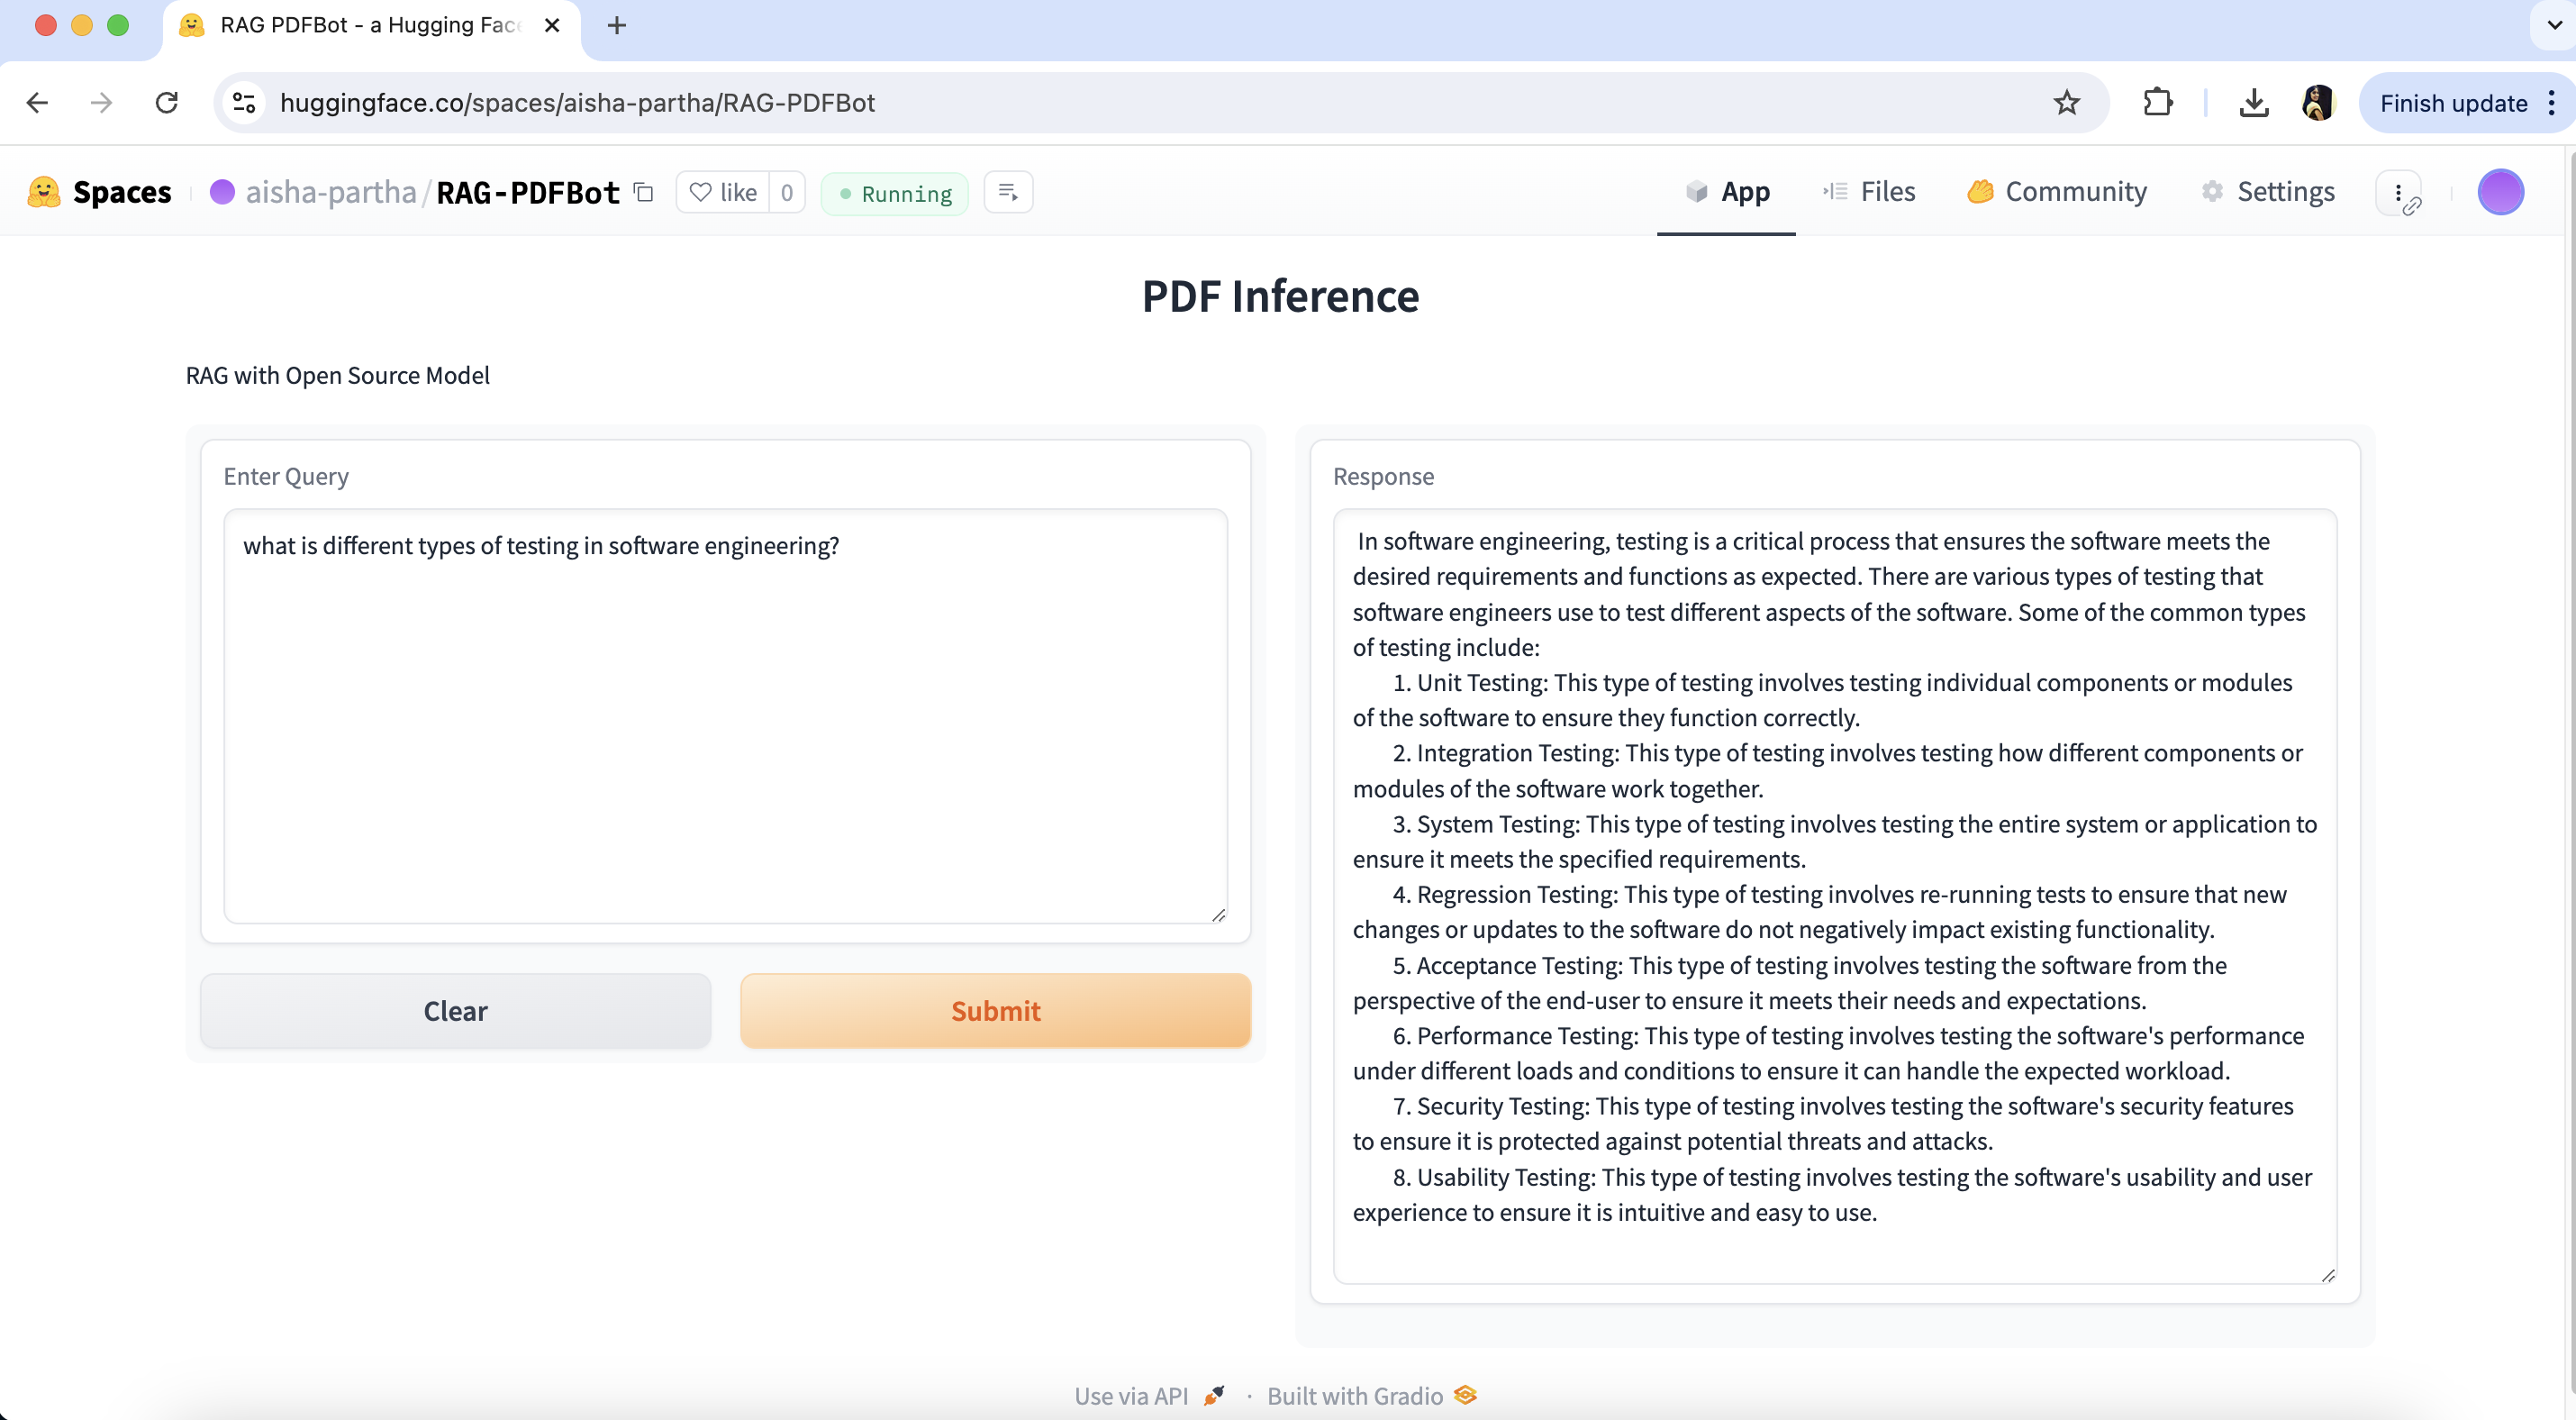